In [1]:
from CNN_utils import *

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

In [3]:
import pandas as pd
# Display with more decimal places
jax.config.update("jax_enable_x64", True)
pd.options.display.float_format = '{:.6f}'.format  # Change decimal places as needed

# Elección de puntos de calibracion

In [4]:
import geopandas as gpd
import rasterio
from rasterio.transform import rowcol
import numpy as np

import arviz as az
import matplotlib.pyplot as plt
import numpy as np

def plot_trace_with_prior_and_true_values(trace, true_n1, true_n2,
                                          prior_lower=0.01, prior_upper=0.085,
                                          output_path="trace_plot_with_prior_posterior_true.png"):
    """
    Plots trace for parameters n1, n2, and sigma, overlays uniform prior density and true values,
    and saves the figure to disk.

    Parameters:
    - trace: ArviZ InferenceData or trace object
    - true_n1: float, true value of n1
    - true_n2: float, true value of n2
    - prior_lower: float, lower bound of the uniform prior
    - prior_upper: float, upper bound of the uniform prior
    - output_path: str, file name to save the plot
    """

    prior_height = 1 / (prior_upper - prior_lower)
    x_vals = np.linspace(prior_lower, prior_upper, 100)
    y_vals = np.ones_like(x_vals) * prior_height

    fig = az.plot_trace(trace, var_names=["n1", "n2", "sigma"], figsize=(12, 8))

    # Plot for n1
    ax_n1 = fig[0, 0]
    ax_n1.plot(x_vals, y_vals, color='green', linestyle='-', linewidth=1.5, label="Prior density")
    ax_n1.axvline(true_n1, color="red", linestyle="--", label="True n1")
    ax_n1.axvline(prior_lower, color="gray", linestyle=":", label="Prior lower")
    ax_n1.axvline(prior_upper, color="gray", linestyle=":", label="Prior upper")
    ax_n1.set_ylabel("Density")

    # Plot for n2
    ax_n2 = fig[1, 0]
    ax_n2.plot(x_vals, y_vals, color='green', linestyle='-', linewidth=1.5, label="Prior density")
    ax_n2.axvline(true_n2, color="red", linestyle="--", label="True n2")
    ax_n2.axvline(prior_lower, color="gray", linestyle=":", label="Prior lower")
    ax_n2.axvline(prior_upper, color="gray", linestyle=":", label="Prior upper")
    ax_n2.set_ylabel("Density")

    # Plot for sigma (just set ylabel)
    ax_sigma = fig[2, 0]
    ax_sigma.set_ylabel("Density")

    # Show legend only on the first subplot
    ax_n1.legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Imagen guardada en: {output_path}")

def extract_observations_from_shapefile(shp_file, tiff_file, X_data, depth_true):
    """
    Extrae coordenadas y profundidad real desde puntos en un shapefile.

    Parámetros:
    - shp_file: ruta al shapefile (.shp) con geometría y campo 'id'.
    - tiff_file: raster de referencia geoespacial.
    - X_data: array (1, H, W, 3) que contiene coordenadas x, y, etc.
    - depth_true: array (H, W) con valores de profundidad.

    Retorna:
    - x_coords_out: array con coordenadas X extraídas desde X_data.
    - y_coords_out: array con coordenadas Y extraídas desde X_data.
    - depth_values: array con valores de profundidad desde depth_true.
    """
    gdf = gpd.read_file(shp_file)
    shp_x_coords, shp_y_coords = gdf.geometry.x, gdf.geometry.y

    with rasterio.open(tiff_file) as src:
        rows_cols = [rowcol(src.transform, x, y) for x, y in zip(shp_x_coords, shp_y_coords)]

    x_coords_out = []
    y_coords_out = []
    depth_values = []

    pixel_x = []
    pixel_y = []

    for row, col in rows_cols:
        try:
            x = X_data[row, col, 1]#X_data[0, row, col, 1]
            y = X_data[row, col, 2]#X_data[0, row, col, 2]
            d_true = depth_true[row, col]

            x_coords_out.append(x)
            y_coords_out.append(y)
            pixel_x.append(row)
            pixel_y.append(col)
            depth_values.append(d_true)
        except IndexError:
            continue

    return np.array(pixel_x), np.array(pixel_y), np.array(x_coords_out), np.array(y_coords_out), np.array(depth_values)

# Cargar modelo

In [5]:
correlation_map_train = np.load("correlation_map_train.npy")
X_train = np.load("x_cov.npy")

In [6]:
from flax.training import checkpoints
import os

# =======================
# Inicializar modelo base
# =======================
rng = jax.random.PRNGKey(0)
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

model = CNNModel(use_correlation=False)
#params = model.init(rng, X_train[:1], get_correlation_map_batch(correlation_map_train, 1))
params = model.init(rng, X_train, get_correlation_map_batch(correlation_map_train, 1))
#params = model.init(rng, dummy_input, get_correlation_map_batch(correlation_map_train, 1))
state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

# =======================
# Restaurar desde checkpoint
# =======================
ckpt_dir = os.path.abspath("D:/Proyectos_GitHub/adao_tests/notebooks/checkpoints_nn")
state = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=state)

print("✅ Estado restaurado desde el checkpoint más reciente.")

✅ Estado restaurado desde el checkpoint más reciente.


In [7]:
n_true = np.load("n_true.npy") #X_val[2,:,:,0]
# Suponiendo que tu array se llama 'arr'
values, counts = np.unique(n_true, return_counts=True)

# Obtener los dos valores más frecuentes
top_indices = np.argsort(-counts)[:2]
top_values = values[top_indices]
top_counts = counts[top_indices]

# Mostrar los resultados
for val, count in zip(top_values, top_counts):
    print(f"Valor: {val}, Frecuencia: {count}")

Valor: 0.0272, Frecuencia: 89099
Valor: 0.057, Frecuencia: 79284


In [22]:
sigma = 0.1 
ruido = np.random.normal(loc=0, scale=sigma, size=(387, 450, 1))
# 🔹 **Cargar datos asegurando `float64`**
x_cov = np.load("x_cov.npy")#X_train[0,:,:,:]
true_image = np.load("y_true.npy") + ruido
correlation_map = jnp.array(np.load("correlation_map_train.npy"))
# ✅ **Asegurar que `true_image` tiene la forma correcta**
true_image = np.squeeze(true_image)  # Elimina dimensiones de tamaño 1 si exist

# MvNormal

In [23]:
pixel_x, pixel_y, coords_x, coords_y, observed_values = extract_observations_from_shapefile(
    shp_file="D:/depths/TIF/CORRELATION/puntos_calibracion.shp",
    tiff_file="D:/depths/TIF/DEPTHS/depth_0.010_0.055.tiff",
    X_data=x_cov,
    depth_true=true_image
)

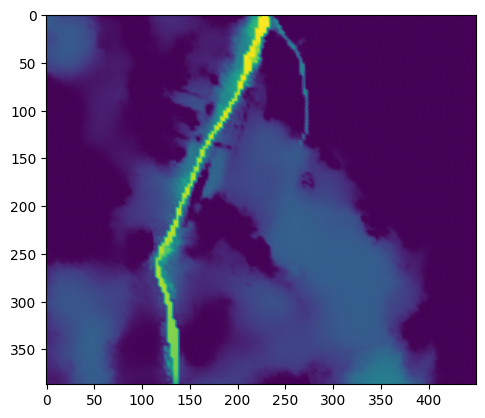

In [24]:
imagen = cnn_predict(x_cov,state, 0.03, 0.04,correlation_map)
plt.imshow(imagen)
plt.show()

# Inadecuación

La función observada se modela como:

$$
z(x) = S(x, \theta) + \delta(x) + \varepsilon(x)
$$

con:

$$
\delta(x) \sim \mathcal{GP}\left(\beta_1 x + \beta_2 y,\; \sigma_\delta^2 \exp\left[-\omega_x (x_i - x_i')^2 - \omega_y (y_i - y_i')^2\right]\right)
$$

$$
\varepsilon(x) \sim \mathcal{N}(0,\; \sigma^2 I)
$$



In [25]:
def build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, pixel_x, pixel_y, observed_values, use_discrepancy=True):
    with pm.Model() as model:
        # Priors
        n1 = pm.Uniform("n1", lower=0.01, upper=0.085)
        n2 = pm.Uniform("n2", lower=0.01, upper=0.085)
        sigma = pm.HalfNormal("sigma", sigma=1.0)

        # Input tensor
        x_cov_t = pt.as_tensor_variable(x_cov)

        # CNN emulator (η)
        cnn_op = CNNPredictOp(model_state=state, correlation_map=correlation_map)
        depth_mean = cnn_op(x_cov_t, n1, n2)
        depth_full = pt.reshape(depth_mean, true_image.shape)
        #S_xtheta = depth_full[coords_y, coords_x]  # Emulator output η(x, θ)
        S_xtheta = depth_full[pixel_x, pixel_y]  # Emulator output η(x, θ)

        # Likelihood setup
        n_obs = observed_values.shape[0]

        if use_discrepancy:
            # GP params
            sigma_delta = pm.HalfNormal("sigma_delta", sigma=1.0)
            beta_x = pm.Normal("beta_x", mu=0, sigma=1)
            beta_y = pm.Normal("beta_y", mu=0, sigma=1)
            omega_x = pm.Gamma("omega_x", alpha=2, beta=1)
            omega_y = pm.Gamma("omega_y", alpha=2, beta=1)

            # Coordenadas observadas
            x1 = pt.as_tensor_variable(coords_x).reshape((-1, 1))
            x2 = pt.as_tensor_variable(coords_x).reshape((1, -1))
            y1 = pt.as_tensor_variable(coords_y).reshape((-1, 1))
            y2 = pt.as_tensor_variable(coords_y).reshape((1, -1))

            sq_dist = omega_x * pt.sqr(x1 - x2) + omega_y * pt.sqr(y1 - y2)
            K = sigma_delta**2 * pt.exp(-sq_dist)

            # GP mean
            mean_gp = beta_x * coords_x + beta_y * coords_y

            mu_total = S_xtheta + mean_gp
            Sigma = K + pt.eye(n_obs) * sigma**2
        else:
            mu_total = S_xtheta
            Sigma = pt.eye(n_obs) * sigma**2

        # Likelihood
        pm.MvNormal(
            "observed",
            mu=mu_total,
            cov=Sigma,
            observed=observed_values
        )

    return model


## Sin discrepancia estructural

In [26]:
# Modelo con discrepancia estructural
#model = build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, observed_values, use_discrepancy=True)

model1 = build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, pixel_x, pixel_y, observed_values, use_discrepancy=False)
with model1:
    step = pm.Slice()
    trace1 = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=10,
        step=step,
        idata_kwargs={"log_likelihood": False}
    )


Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Slice: [n1]
INFO:pymc.sampling.mcmc:>Slice: [n1]
>Slice: [n2]
INFO:pymc.sampling.mcmc:>Slice: [n2]
>Slice: [sigma]
INFO:pymc.sampling.mcmc:>Slice: [sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7351 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7351 seconds.


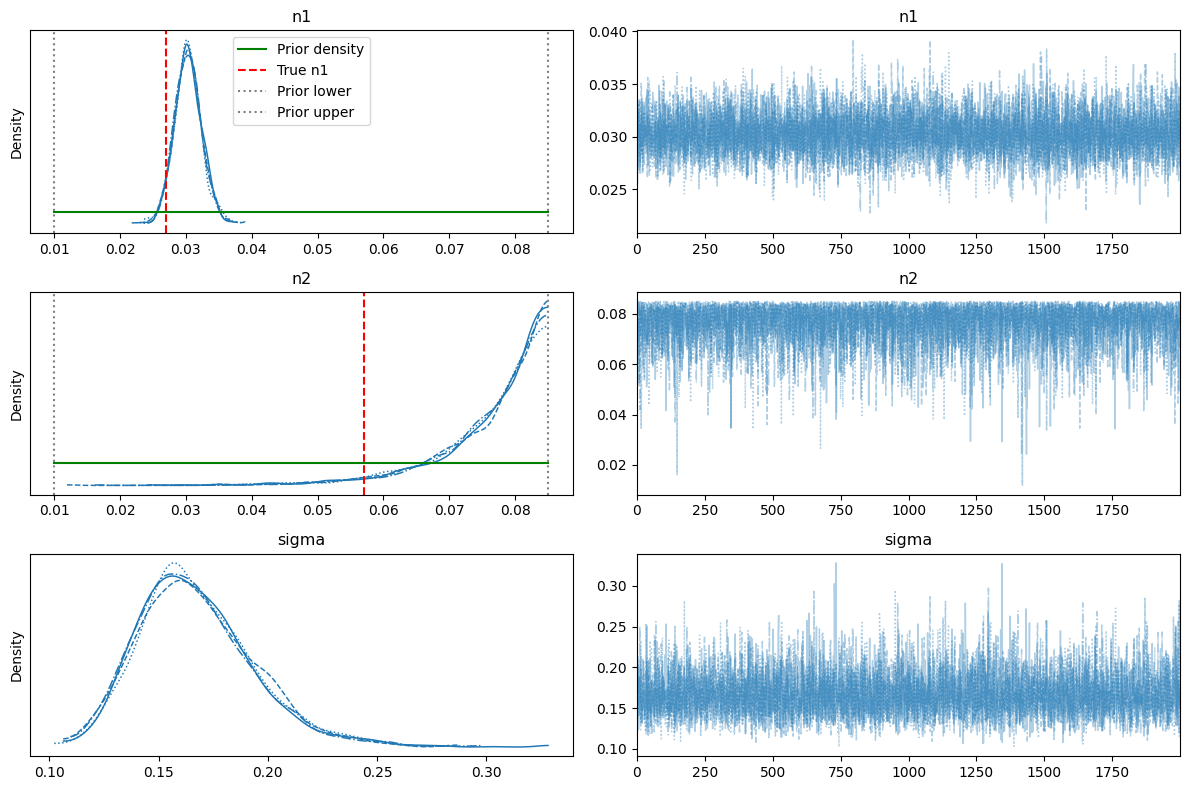

✅ Imagen guardada en: modelo_sin_discrepancia_estructural.png


In [33]:
plot_trace_with_prior_and_true_values(
    trace=trace1,
    true_n1=0.027,
    true_n2=0.057,
    prior_lower=0.01,
    prior_upper=0.085,
    output_path="modelo_sin_discrepancia_estructural.png"
)

In [8]:
import arviz as az

# Cargar como InferenceData
trace1 = az.from_netcdf("trace_nvm_file.nc")


In [9]:
# Obtener resumen estadístico del trazado
summary = az.summary(trace1)

# Mostrar el resumen
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
n1,0.030000,0.002000,0.026000,0.034000,0.000000,0.000000,7066.000000,5466.000000,1.000000
n2,0.077000,0.008000,0.061000,0.085000,0.000000,0.000000,5179.000000,4719.000000,1.000000
sigma,0.167000,0.027000,0.121000,0.217000,0.000000,0.000000,6074.000000,5567.000000,1.000000


In [13]:
summary.to_excel("tabla_resumen_cnn.xlsx",index=True)

In [32]:
#az.to_netcdf(trace1, "trace_nvm_file.nc")

'trace_nvm_file.nc'

In [30]:
ess = az.ess(trace1)
print(ess)

<xarray.Dataset> Size: 24B
Dimensions:  ()
Data variables:
    n1       float64 8B 7.066e+03
    n2       float64 8B 5.179e+03
    sigma    float64 8B 6.074e+03


## Con discrepancia estructura

In [11]:
sigma = 0.1 
ruido = np.random.normal(loc=0, scale=sigma, size=(387, 450, 1))
# 🔹 **Cargar datos asegurando `float64`**
x_cov = np.load("x_cov.npy")#X_train[0,:,:,:]
b1_true = 0.3
b2_true = 0.8
true_image = np.load("y_true.npy") + ruido
correlation_map = jnp.array(np.load("correlation_map_train.npy"))
# ✅ **Asegurar que `true_image` tiene la forma correcta**
true_image = np.squeeze(true_image) + b1_true*x_cov[:,:,1] + b2_true *x_cov[:,:,2] # Elimina dimensiones de tamaño 1 si exist

In [12]:
pixel_x, pixel_y, coords_x, coords_y, observed_values = extract_observations_from_shapefile(
    shp_file="D:/depths/TIF/CORRELATION/puntos_calibracion.shp",
    tiff_file="D:/depths/TIF/DEPTHS/depth_0.010_0.055.tiff",
    X_data=x_cov,
    depth_true=true_image
)

In [13]:
model2 = build_model(x_cov, state, correlation_map, true_image, coords_y, coords_x, pixel_x, pixel_y, observed_values, use_discrepancy=True)
with model2:
    step = pm.Slice()
    trace2 = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=4,
        step=step,
        idata_kwargs={"log_likelihood": False}
    )


Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Slice: [n1]
INFO:pymc.sampling.mcmc:>Slice: [n1]
>Slice: [n2]
INFO:pymc.sampling.mcmc:>Slice: [n2]
>Slice: [sigma]
INFO:pymc.sampling.mcmc:>Slice: [sigma]
>Slice: [sigma_delta]
INFO:pymc.sampling.mcmc:>Slice: [sigma_delta]
>Slice: [beta_x]
INFO:pymc.sampling.mcmc:>Slice: [beta_x]
>Slice: [beta_y]
INFO:pymc.sampling.mcmc:>Slice: [beta_y]
>Slice: [omega_x]
INFO:pymc.sampling.mcmc:>Slice: [omega_x]
>Slice: [omega_y]
INFO:pymc.sampling.mcmc:>Slice: [omega_y]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20104 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20104 seconds.


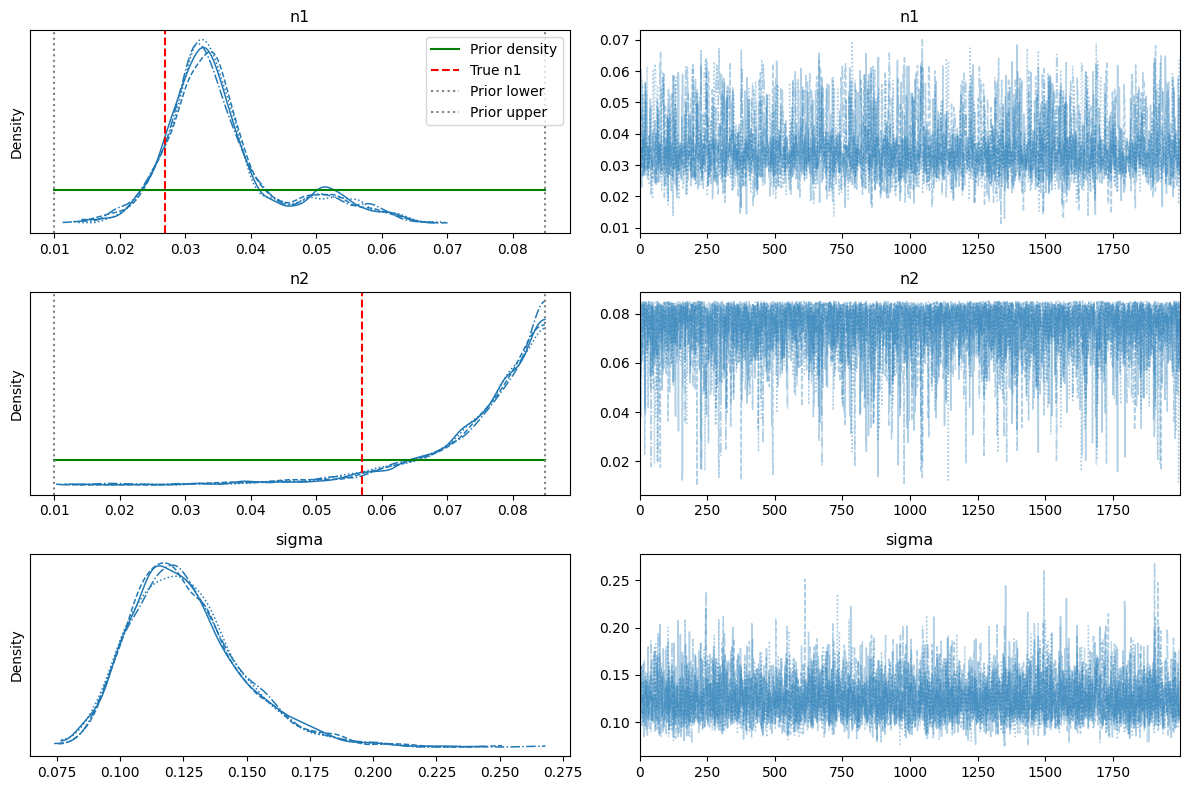

✅ Imagen guardada en: modelo_discrepancia_estructural.png


In [14]:
plot_trace_with_prior_and_true_values(
    trace=trace2,
    true_n1=0.027,
    true_n2=0.057,
    prior_lower=0.01,
    prior_upper=0.085,
    output_path="modelo_discrepancia_estructural.png"
)

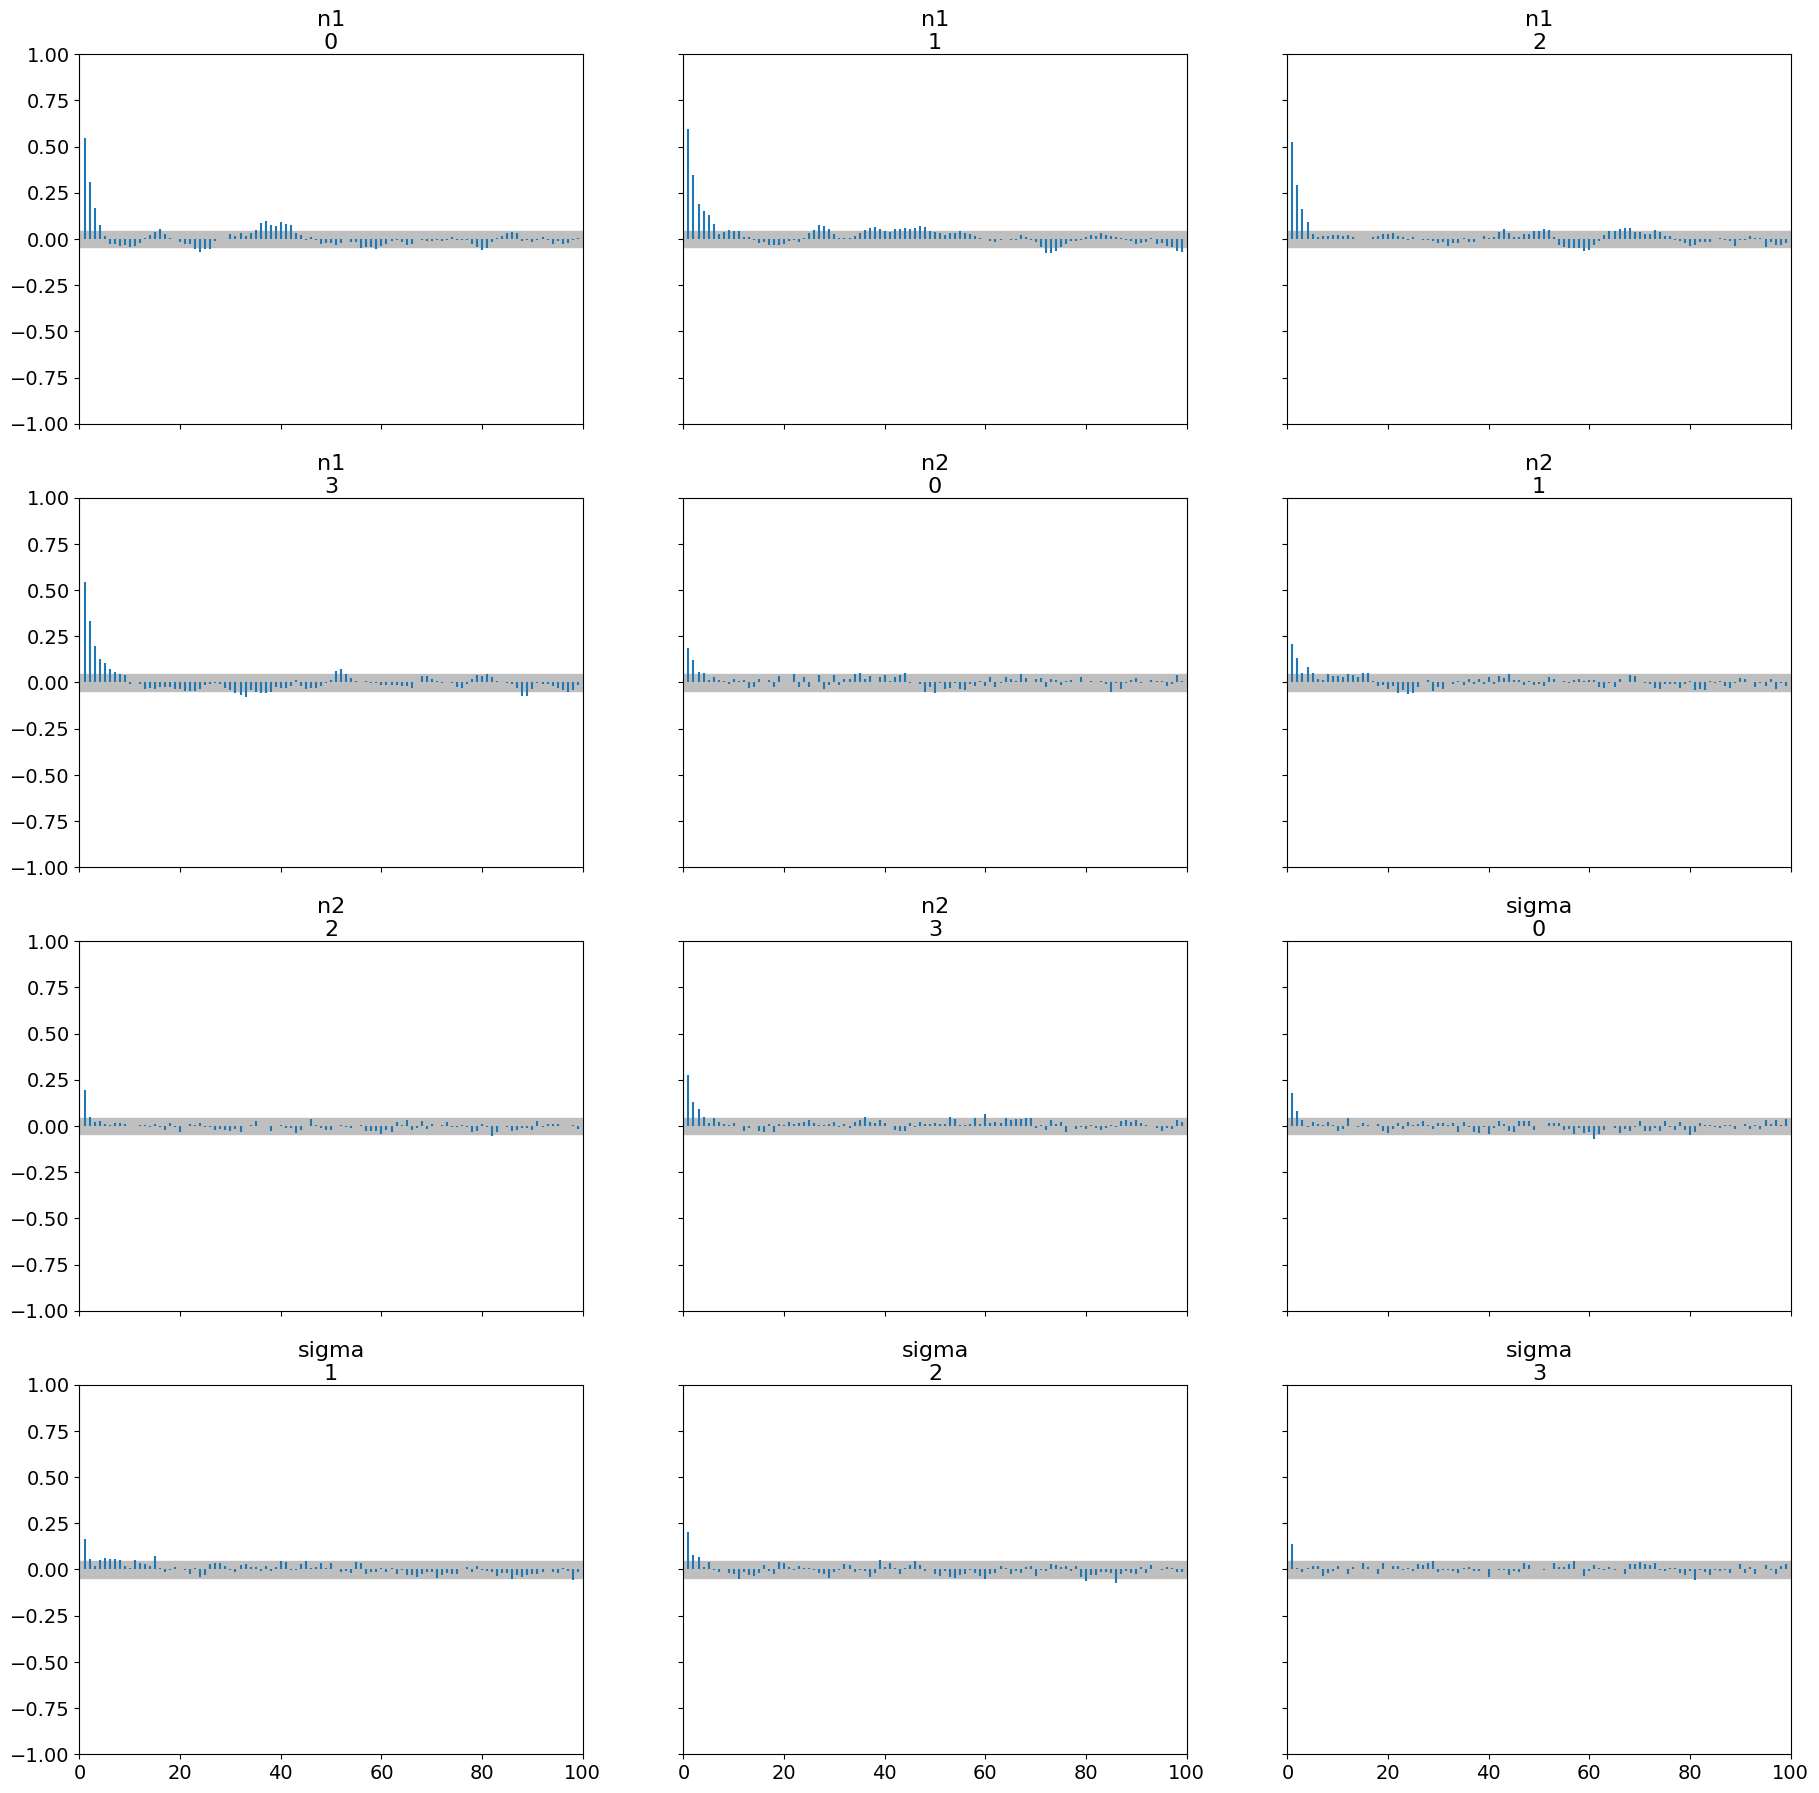

In [14]:
import arviz as az

# Cargar como InferenceData
trace2 = az.from_netcdf("trace_nvm__structural_file.nc")
az.plot_autocorr(trace2, var_names=["n1", "n2", "sigma"])
plt.show()

In [15]:
# Obtener resumen estadístico del trazado
summary = az.summary(trace2)

# Mostrar el resumen
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_x,0.113000,0.414000,-0.684000,0.922000,0.008000,0.009000,2701.000000,2878.000000,1.000000
beta_y,0.851000,0.270000,0.317000,1.364000,0.004000,0.007000,3745.000000,4023.000000,1.000000
n1,0.036000,0.009000,0.022000,0.057000,0.000000,0.000000,2755.000000,2677.000000,1.000000
n2,0.074000,0.011000,0.055000,0.085000,0.000000,0.000000,4042.000000,4070.000000,1.000000
sigma,0.126000,0.022000,0.087000,0.167000,0.000000,0.000000,4952.000000,4943.000000,1.000000
sigma_delta,0.194000,0.200000,0.000000,0.558000,0.005000,0.006000,1737.000000,2789.000000,1.000000
omega_x,1.851000,1.322000,0.044000,4.222000,0.015000,0.019000,6697.000000,4502.000000,1.000000
omega_y,1.861000,1.368000,0.052000,4.397000,0.016000,0.019000,6317.000000,5057.000000,1.000000


In [16]:
summary.to_excel('calibration_structural.xlsx',index=True)

In [18]:
#az.to_netcdf(trace2, "trace_nvm__structural_file.nc")

'trace_nvm__structural_file.nc'